# 1. For Diagonal Co-Variance matrix

Classifier Accuracy: 62.81%
Confusion Matrix:
[[450 248]
 [298 472]]
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.64      0.62       698
           1       0.66      0.61      0.63       770

    accuracy                           0.63      1468
   macro avg       0.63      0.63      0.63      1468
weighted avg       0.63      0.63      0.63      1468

Mean Precision: 0.63
Mean Recall: 0.63
Mean F-measure: 0.63


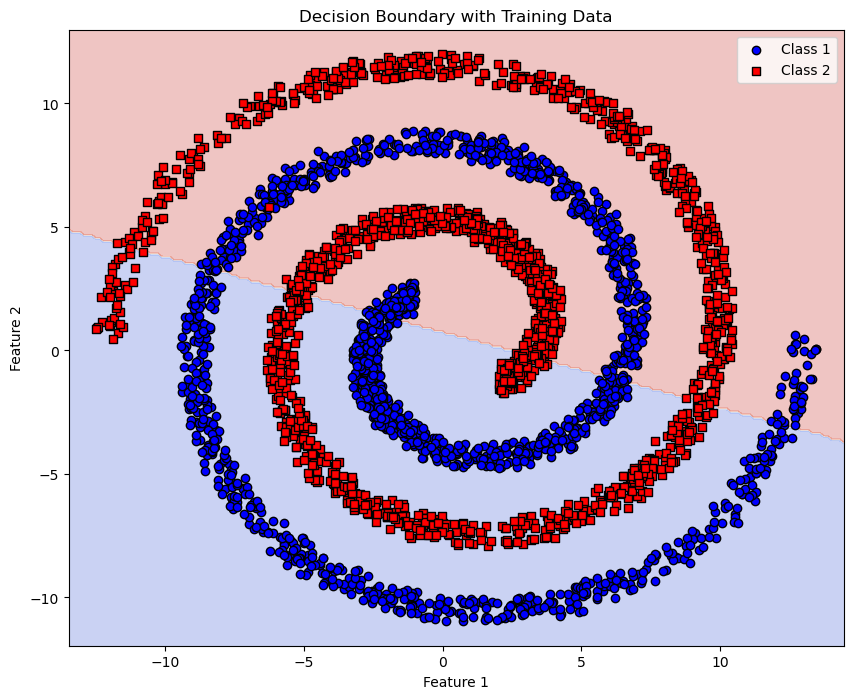

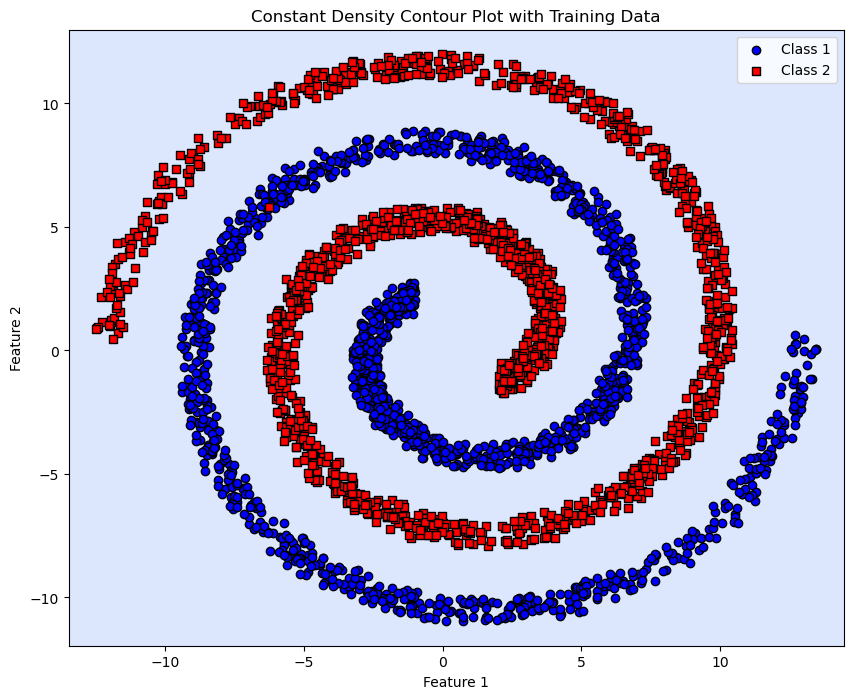

<Figure size 1000x800 with 0 Axes>

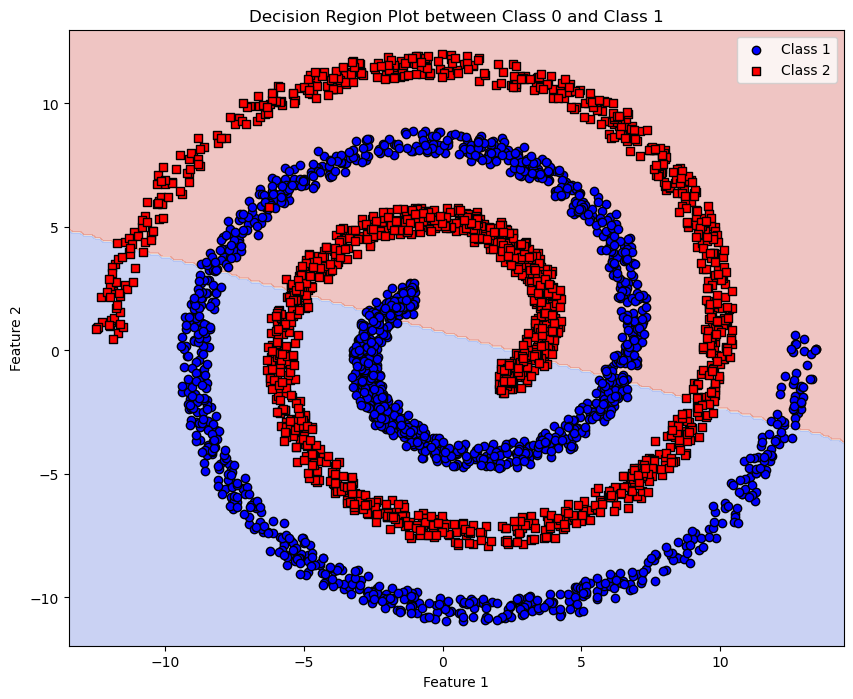

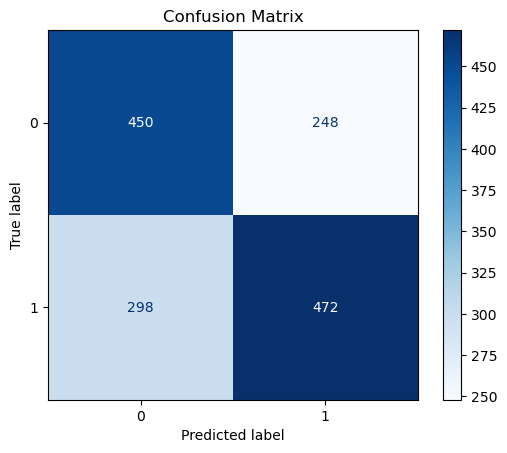

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load the data from the files
class1_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class1.txt')
class2_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class2.txt')

# Combine the data and create labels
X = np.vstack((class1_data, class2_data))
y = np.array([0]*class1_data.shape[0] + [1]*class2_data.shape[0])

# Split the data into training and test sets (70% train, 30% test)
def train_test_split(data, labels, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(data))
    split_idx = int(len(data) * (1 - test_size))
    return data[indices[:split_idx]], data[indices[split_idx:]], labels[indices[:split_idx]], labels[indices[split_idx:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Compute the mean and covariance matrix for each class
def compute_mean_covariance(X, y):
    classes = np.unique(y)
    means = {}
    covariances = {}
    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        covariances[c] = np.cov(X_c, rowvar=False)
    return means, covariances

means, covariances = compute_mean_covariance(X_train, y_train)

# Calculate the average covariance matrix (for shared covariance assumption)
average_covariance = np.mean(list(covariances.values()), axis=0)
# Convert the full covariance to diagonal covariance (σ^2 * I)
average_variance = np.mean(np.diag(average_covariance))
shared_covariance = average_variance * np.eye(X_train.shape[1])

# Define function to calculate multivariate Gaussian PDF in log-space
def multivariate_gaussian_pdf(x, mean, cov):
    size = len(x)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    norm_const = -0.5 * (size * np.log(2 * np.pi) + np.log(det_cov))
    x_mu = x - mean
    result = np.sum(x_mu @ inv_cov * x_mu, axis=1)
    return np.exp(norm_const - 0.5 * result)

# Define the Bayes classifier manually
def bayes_classifier(X, means, shared_cov, priors):
    y_pred = []
    for x in X:
        posteriors = []
        for c in means.keys():
            prior = np.log(priors[c])
            likelihood = np.log(multivariate_gaussian_pdf(np.array([x]), means[c], shared_cov))
            posterior = prior + likelihood
            posteriors.append(posterior)
        y_pred.append(np.argmax(posteriors))
    return np.array(y_pred)

# Define the priors (assuming equal priors for simplicity)
priors = {0: 0.5, 1: 0.5}

# Predict using the manual Bayes classifier
y_pred = bayes_classifier(X_test, means, shared_covariance, priors)

# Calculate and print accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix and classification metrics
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
mean_precision = np.mean([report[str(i)]['precision'] for i in report if i.isdigit()])
mean_recall = np.mean([report[str(i)]['recall'] for i in report if i.isdigit()])
mean_fmeasure = np.mean([report[str(i)]['f1-score'] for i in report if i.isdigit()])

print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
print(f"Mean Precision: {mean_precision:.2f}")
print(f"Mean Recall: {mean_recall:.2f}")
print(f"Mean F-measure: {mean_fmeasure:.2f}")

# Plotting decision boundaries and training data
def plot_decision_boundary(X, y, means, cov, priors, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = bayes_classifier(grid, means, cov, priors)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(X_train, y_train, means, shared_covariance, priors, 'Decision Boundary with Training Data')

# Constant density contour plot
def plot_density_contour(X, y, means, cov, priors):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = np.zeros(grid.shape[0])
    for c in means.keys():
        Z += multivariate_gaussian_pdf(grid, means[c], shared_covariance)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Constant Density Contour Plot with Training Data')
    plt.legend()
    plt.show()

plot_density_contour(X_train, y_train, means, shared_covariance, priors)

# Decision region plot between each pair of classes
def plot_decision_region(X, y, means, cov, priors):
    classes = np.unique(y)
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            X_pair = X[(y == classes[i]) | (y == classes[j])]
            y_pair = y[(y == classes[i]) | (y == classes[j])]
            means_pair = {classes[i]: means[classes[i]], classes[j]: means[classes[j]]}

            plt.figure(figsize=(10, 8))
            plot_decision_boundary(X_pair, y_pair, means_pair, cov, priors,
                                   f'Decision Region Plot between Class {classes[i]} and Class {classes[j]}')

plot_decision_region(X_train, y_train, means, shared_covariance, priors)

# Confusion matrix visualization
def plot_confusion_matrix(cm):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(conf_matrix)


Classifier Accuracy: 62.81%
Confusion Matrix:
[[450 248]
 [298 472]]
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.64      0.62       698
           1       0.66      0.61      0.63       770

    accuracy                           0.63      1468
   macro avg       0.63      0.63      0.63      1468
weighted avg       0.63      0.63      0.63      1468

Mean Precision: 0.63
Mean Recall: 0.63
Mean F-measure: 0.63


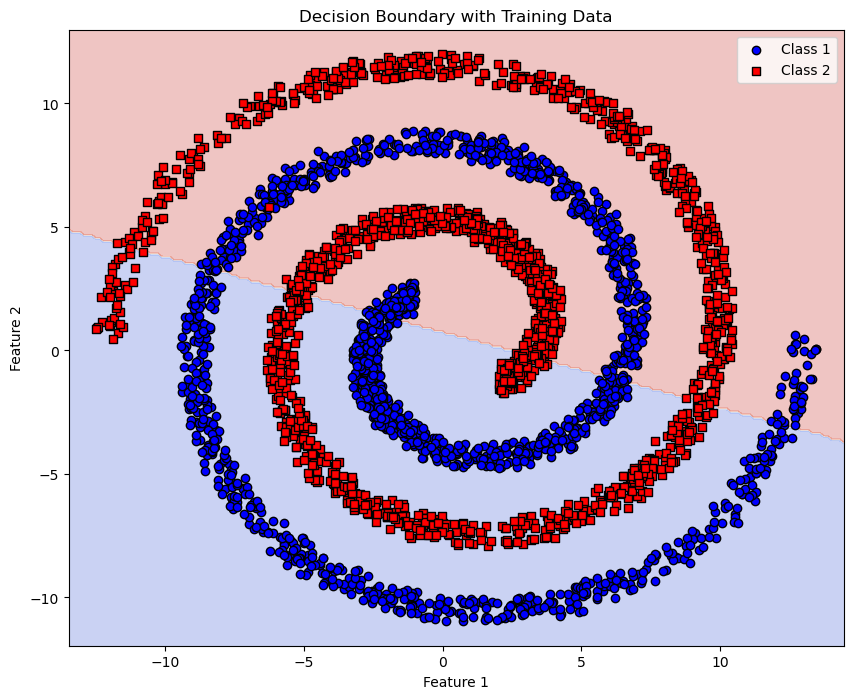

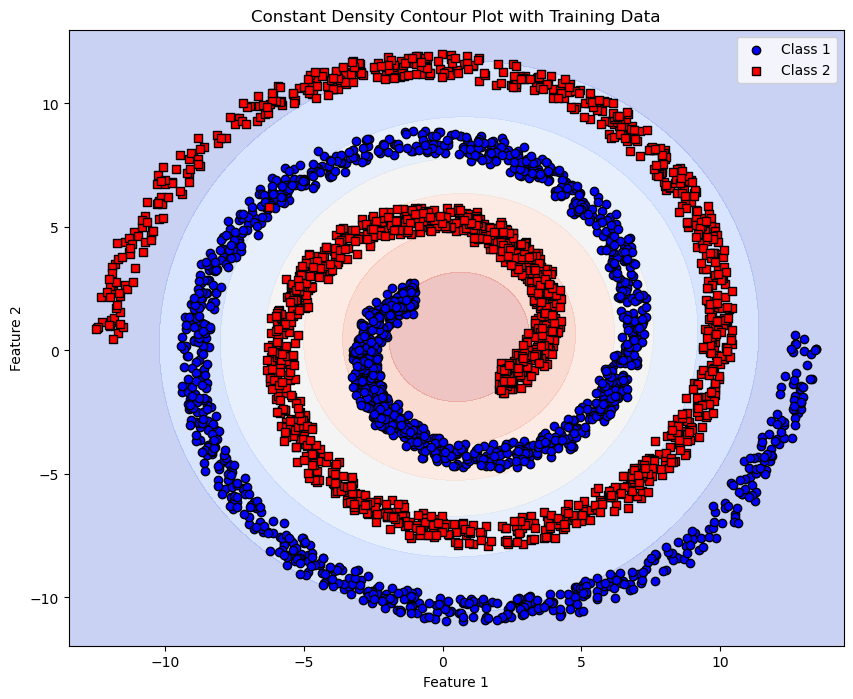

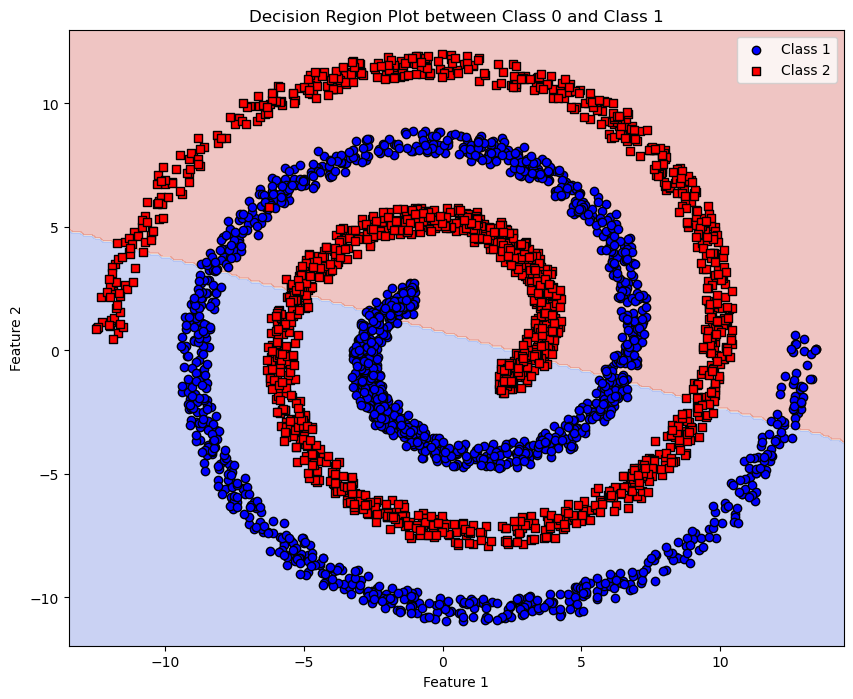

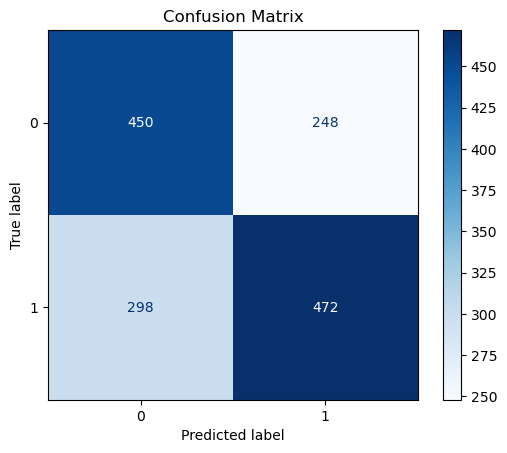

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load the data from the files
class1_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class1.txt')
class2_data = np.loadtxt('C:\\Users\\saura\\Desktop\\assignment spr\\assignment1\\MY_data_set\\Group03\\Group03\\NSL_Group03\\class2.txt')

# Combine the data and create labels
X = np.vstack((class1_data, class2_data))
y = np.array([0]*class1_data.shape[0] + [1]*class2_data.shape[0])

# Split the data into training and test sets (70% train, 30% test)
def train_test_split(data, labels, test_size=0.3, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(len(data))
    split_idx = int(len(data) * (1 - test_size))
    return data[indices[:split_idx]], data[indices[split_idx:]], labels[indices[:split_idx]], labels[indices[split_idx:]]

X_train, X_test, y_train, y_test = train_test_split(X, y)

# Compute the mean and covariance matrix for each class
def compute_mean_covariance(X, y):
    classes = np.unique(y)
    means = {}
    covariances = {}
    for c in classes:
        X_c = X[y == c]
        means[c] = np.mean(X_c, axis=0)
        covariances[c] = np.cov(X_c, rowvar=False)
    return means, covariances

means, covariances = compute_mean_covariance(X_train, y_train)

# Calculate the average covariance matrix (for shared covariance assumption)
average_covariance = np.mean(list(covariances.values()), axis=0)
# Convert the full covariance to diagonal covariance (σ^2 * I)
average_variance = np.mean(np.diag(average_covariance))
shared_covariance = average_variance * np.eye(X_train.shape[1])

# Define function to calculate multivariate Gaussian PDF in log-space
def multivariate_gaussian_pdf(x, mean, cov):
    size = len(mean)
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    norm_const = -0.5 * (size * np.log(2 * np.pi) + np.log(det_cov))
    x_mu = x - mean
    result = np.sum(x_mu @ inv_cov * x_mu, axis=1)
    return np.exp(norm_const - 0.5 * result)

# Define the Bayes classifier manually
def bayes_classifier(X, means, cov, priors):
    log_priors = {c: np.log(prior) for c, prior in priors.items()}
    y_pred = []
    for x in X:
        log_posteriors = []
        for c in means.keys():
            log_likelihood = np.log(multivariate_gaussian_pdf(np.array([x]), means[c], cov))
            log_posterior = log_priors[c] + log_likelihood
            log_posteriors.append(log_posterior)
        y_pred.append(np.argmax(log_posteriors))
    return np.array(y_pred)

# Define the priors (assuming equal priors for simplicity)
priors = {0: 0.5, 1: 0.5}

# Predict using the manual Bayes classifier
y_pred = bayes_classifier(X_test, means, shared_covariance, priors)

# Calculate and print accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Classifier Accuracy: {accuracy * 100:.2f}%")

# Confusion matrix and classification metrics
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
mean_precision = np.mean([report[str(i)]['precision'] for i in report if i.isdigit()])
mean_recall = np.mean([report[str(i)]['recall'] for i in report if i.isdigit()])
mean_fmeasure = np.mean([report[str(i)]['f1-score'] for i in report if i.isdigit()])

print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
print(f"Mean Precision: {mean_precision:.2f}")
print(f"Mean Recall: {mean_recall:.2f}")
print(f"Mean F-measure: {mean_fmeasure:.2f}")

# Plotting decision boundaries and training data
def plot_decision_boundary(X, y, means, cov, priors, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = bayes_classifier(grid, means, cov, priors)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(X_train, y_train, means, shared_covariance, priors, 'Decision Boundary with Training Data')

# Constant density contour plot
def plot_density_contour(X, y, means, cov):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = np.zeros(grid.shape[0])
    for c in means.keys():
        Z += multivariate_gaussian_pdf(grid, means[c], shared_covariance)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='blue', label='Class 1', edgecolors='k', marker='o')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='red', label='Class 2', edgecolors='k', marker='s')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Constant Density Contour Plot with Training Data')
    plt.legend()
    plt.show()

plot_density_contour(X_train, y_train, means, shared_covariance)

# Decision region plot between each pair of classes
def plot_decision_region(X, y, means, cov, priors):
    classes = np.unique(y)
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            X_pair = X[(y == classes[i]) | (y == classes[j])]
            y_pair = y[(y == classes[i]) | (y == classes[j])]
            means_pair = {classes[i]: means[classes[i]], classes[j]: means[classes[j]]}

            plot_decision_boundary(X_pair, y_pair, means_pair, cov, priors,
                                   f'Decision Region Plot between Class {classes[i]} and Class {classes[j]}')

plot_decision_region(X_train, y_train, means, shared_covariance, priors)

# Confusion matrix visualization
def plot_confusion_matrix(cm):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(conf_matrix)
